In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/099/profiles/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 36)


,LumA_cntr_1,LumA_cntr_2,LumA_cntr_3,LumA_EGFL7_1,LumA_EGFL7_2,LumA_EGFL7_3,LumA_TSP1_1,LumA_TSP1_2,LumA_TSP1_3,MCF_cntr_1,...,MDA_TSP1_3,TNBC_cntr_1,TNBC_cntr_2,TNBC_cntr_3,TNBC_EGFL7_1,TNBC_EGFL7_2,TNBC_EGFL7_3,TNBC_TSP1_1,TNBC_TSP1_2,TNBC_TSP1_3
ENSG00000000003.15,0.040019,0.089781,0.519165,0.000000,0.315999,0.000000,0.000000,0.048092,0.000000,14.158053,...,16.760681,67.389293,84.811050,69.631305,76.525148,52.714032,55.194360,63.718462,67.283530,56.652326
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.211035,0.000000,0.000000,0.000000
ENSG00000000419.14,162.064150,169.654331,142.031667,166.517821,170.330102,166.841653,137.352315,154.636585,149.416957,136.794417,...,104.667481,148.580333,164.016421,167.609588,145.648434,112.709104,140.455765,141.516632,154.121783,128.085301
ENSG00000000457.14,6.176962,7.375785,7.332816,8.889273,6.544422,7.078984,5.510540,6.561009,9.114917,6.225286,...,6.195762,17.746407,15.814583,13.389940,15.735016,11.670259,12.231737,17.378157,13.179884,13.108420
ENSG00000000460.17,12.456095,24.100438,15.638211,16.173852,18.713586,23.606197,14.282523,19.348045,17.091778,19.037781,...,25.172164,36.579583,45.314076,42.454615,41.418952,41.782242,49.196646,44.559718,47.432829,39.800640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.659625,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,8.952618,6.788582,8.093795,9.295223,5.422511,8.309451,10.327118,14.481905,8.615348,2.113153,...,0.918273,6.780081,3.277890,11.392483,4.254464,8.586644,7.133406,11.453285,9.205272,10.765661
ENSG00000291300.1,0.325036,0.414860,0.124098,0.371174,0.424661,0.414071,0.478632,0.184226,0.061749,0.270432,...,0.450895,0.000000,0.000000,0.174172,0.000000,0.000000,0.531655,0.530015,0.000000,0.000000


In [6]:
for element in expression.columns:
    print(element)

LumA_cntr_1
LumA_cntr_2
LumA_cntr_3
LumA_EGFL7_1
LumA_EGFL7_2
LumA_EGFL7_3
LumA_TSP1_1
LumA_TSP1_2
LumA_TSP1_3
MCF_cntr_1
MCF_cntr_2
MCF_cntr_3
MCF_EGFL7_1
MCF_EGFL7_2
MCF_EGFL7_3
MCF_TSP1_1
MCF_TSP1_2
MCF_TSP1_3
MDA_cntr_1
MDA_cntr_2
MDA_cntr_3
MDA_EGFL7_1
MDA_EGFL7_2
MDA_EGFL7_3
MDA_TSP1_1
MDA_TSP1_2
MDA_TSP1_3
TNBC_cntr_1
TNBC_cntr_2
TNBC_cntr_3
TNBC_EGFL7_1
TNBC_EGFL7_2
TNBC_EGFL7_3
TNBC_TSP1_1
TNBC_TSP1_2
TNBC_TSP1_3


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 2]
high_expression = expression[expression.max(axis=1) >= 100]

print(substantial_expression.shape)
print(high_expression.shape)

(19684, 36)
(3658, 36)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.2825384  0.23564465]


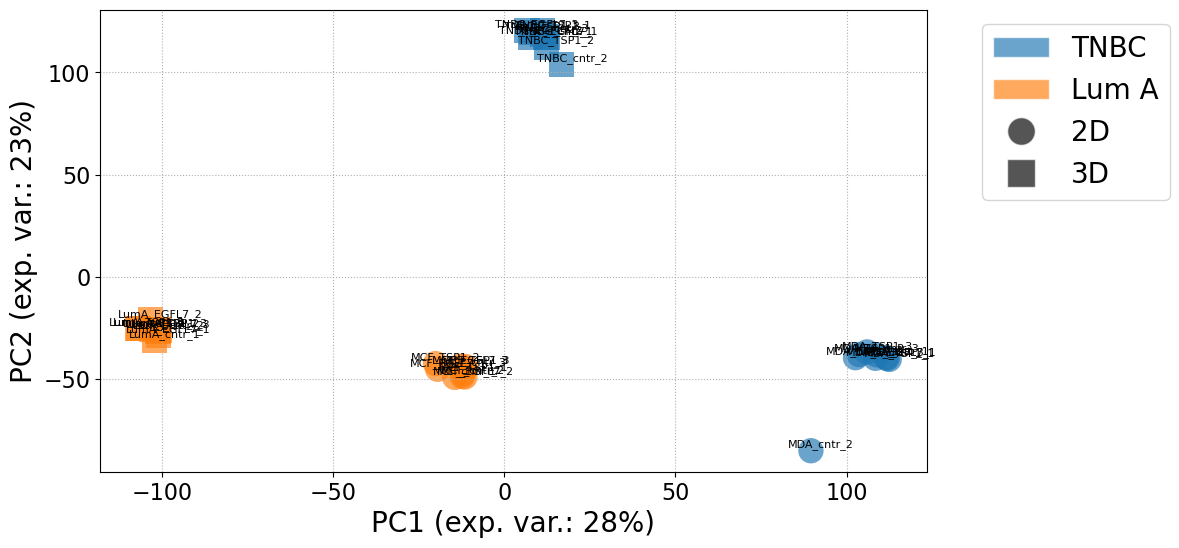

In [10]:
for i in range(len(new)):

    name = expression.columns[i]

    # colors
    if 'LumA' in name or 'MCF' in name:
        the_color = 'tab:orange'
    elif 'TNBC' in name or 'MDA' in name:
        the_color = 'tab:blue'
    else:
        print('error')

    # marker
    if 'LumA' in name or 'TNBC' in name:
        the_marker = 's'
    elif 'MCF' in name or 'MDA' in name:
        the_marker = 'o'
    else:
        print('error')
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=333, c=the_color, marker=the_marker, alpha=2/3, edgecolors='none')
    epsilon=3
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')


legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue', edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange', edgecolor='white', alpha=2/3),
    matplotlib.lines.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], marker='s', color='w', markerfacecolor='black', markersize=20, alpha=2/3),
]

matplotlib.pyplot.legend(legend_elements, ['TNBC', 'Lum A', '2D', '3D'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.37850698 0.25456873]


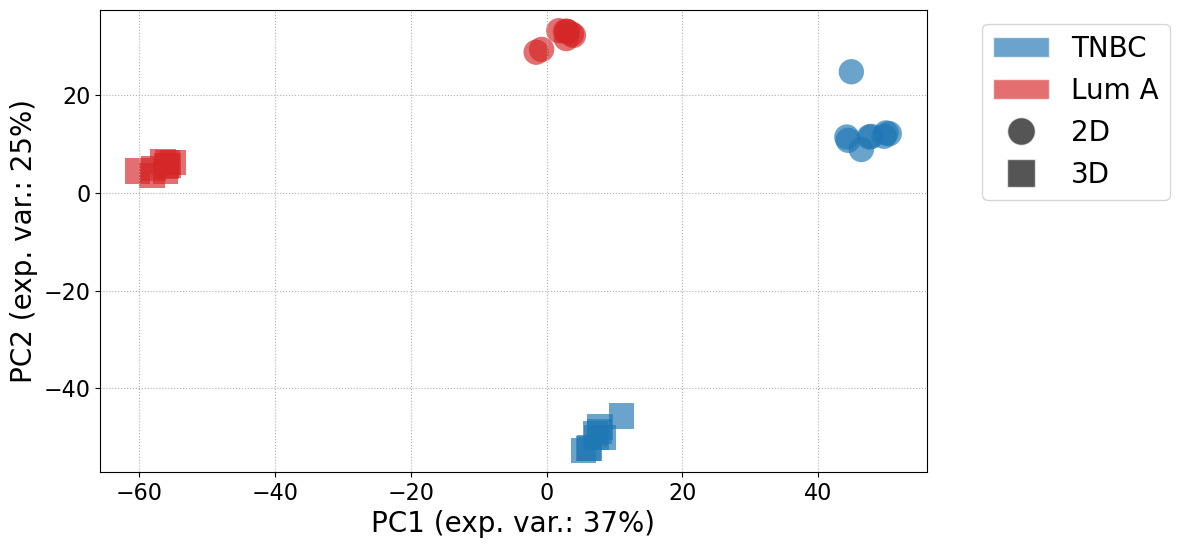

In [12]:
for i in range(len(new)):

    name = expression.columns[i]

    # colors
    if 'LumA' in name or 'MCF' in name:
        the_color = 'tab:red'
    elif 'TNBC' in name or 'MDA' in name:
        the_color = 'tab:blue'
    else:
        print('error')

    # marker
    if 'LumA' in name or 'TNBC' in name:
        the_marker = 's'
    elif 'MCF' in name or 'MDA' in name:
        the_marker = 'o'
    else:
        print('error')
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=333, c=the_color, marker=the_marker, alpha=2/3, edgecolors='none')
    
    #epsilon=3
    #matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue', edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red', edgecolor='white', alpha=2/3),
    matplotlib.lines.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], marker='s', color='w', markerfacecolor='black', markersize=20, alpha=2/3),
]

matplotlib.pyplot.legend(legend_elements, ['TNBC', 'Lum A', '2D', '3D'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

TNBC
(39546, 36)
(39546, 9) Index(['TNBC_cntr_1', 'TNBC_cntr_2', 'TNBC_cntr_3', 'TNBC_EGFL7_1',
       'TNBC_EGFL7_2', 'TNBC_EGFL7_3', 'TNBC_TSP1_1', 'TNBC_TSP1_2',
       'TNBC_TSP1_3'],
      dtype='str')
(2275, 9)
[0.47794673 0.14525772]


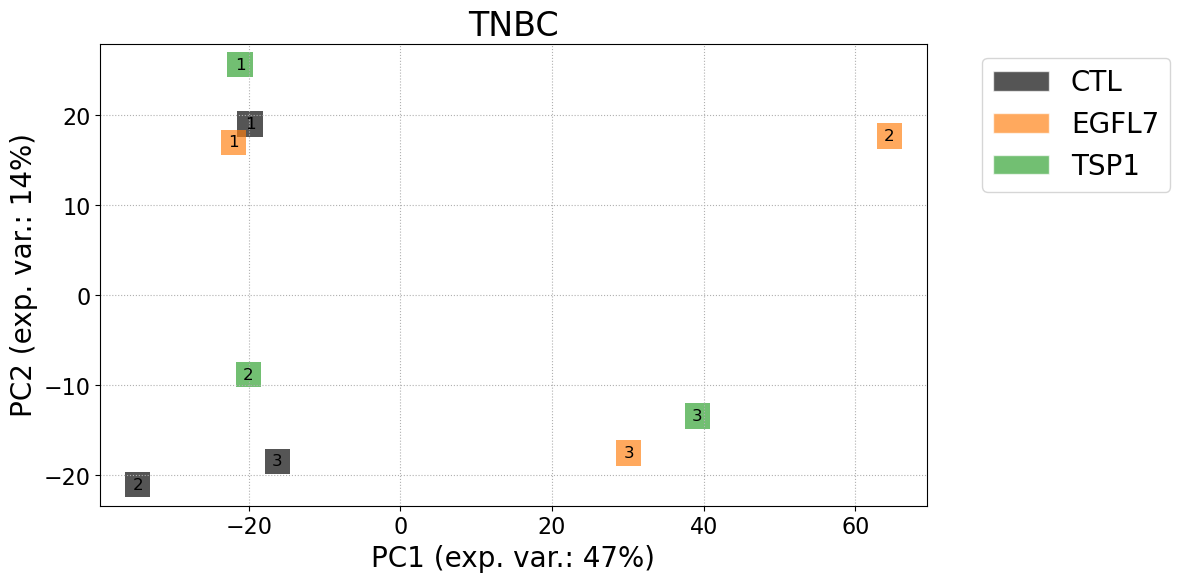

MDA
(39546, 36)
(39546, 9) Index(['MDA_cntr_1', 'MDA_cntr_2', 'MDA_cntr_3', 'MDA_EGFL7_1', 'MDA_EGFL7_2',
       'MDA_EGFL7_3', 'MDA_TSP1_1', 'MDA_TSP1_2', 'MDA_TSP1_3'],
      dtype='str')
(2228, 9)
[0.63328562 0.12912528]


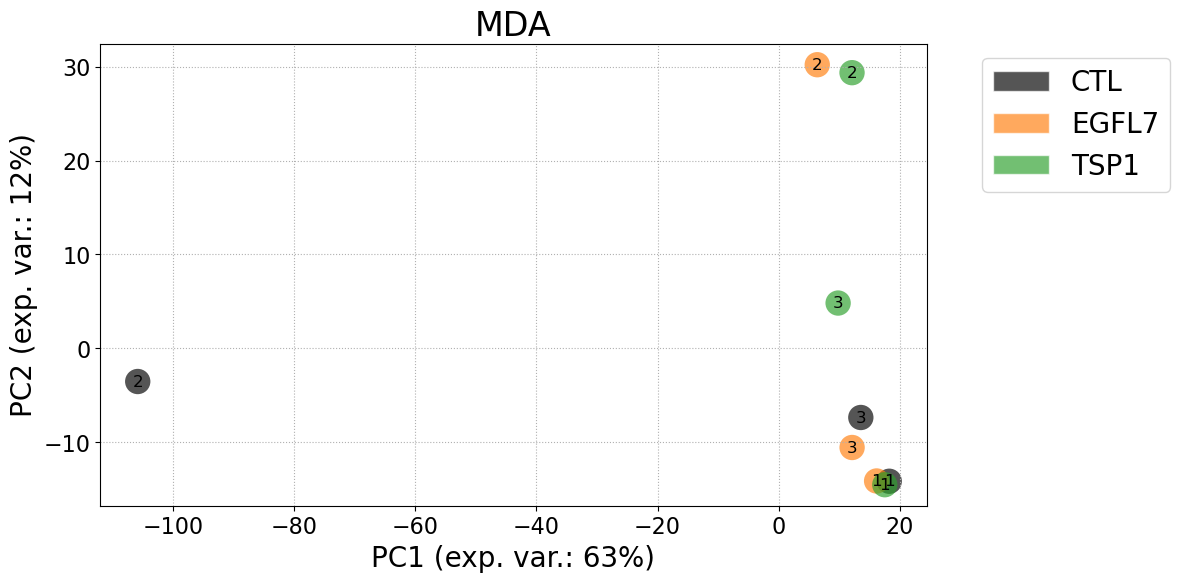

LumA
(39546, 36)
(39546, 9) Index(['LumA_cntr_1', 'LumA_cntr_2', 'LumA_cntr_3', 'LumA_EGFL7_1',
       'LumA_EGFL7_2', 'LumA_EGFL7_3', 'LumA_TSP1_1', 'LumA_TSP1_2',
       'LumA_TSP1_3'],
      dtype='str')
(1953, 9)
[0.34786574 0.24484657]


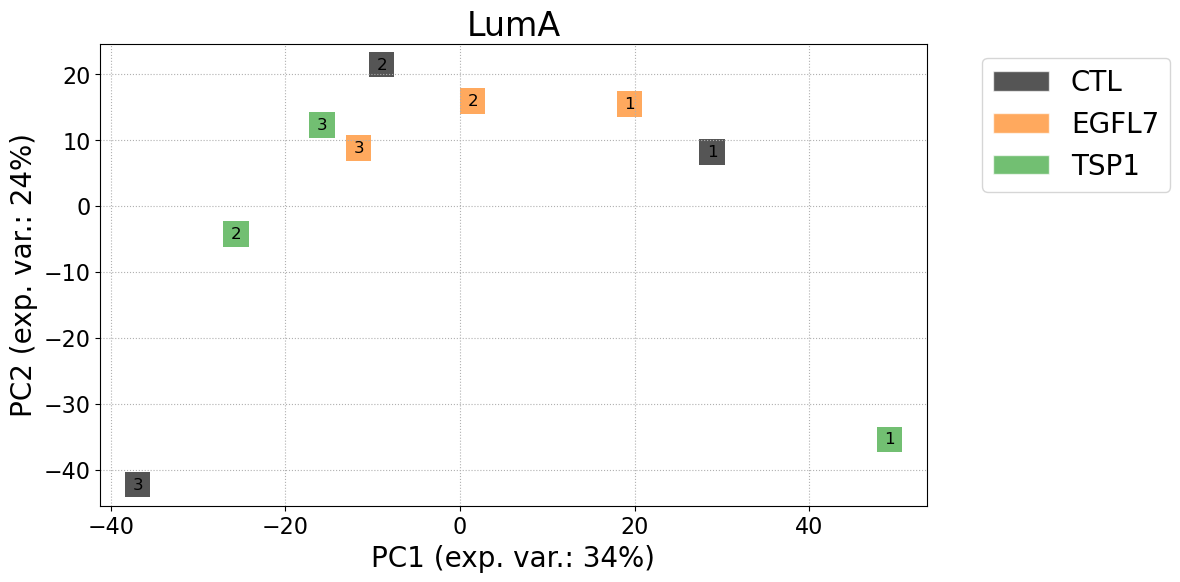

MCF
(39546, 36)
(39546, 9) Index(['MCF_cntr_1', 'MCF_cntr_2', 'MCF_cntr_3', 'MCF_EGFL7_1', 'MCF_EGFL7_2',
       'MCF_EGFL7_3', 'MCF_TSP1_1', 'MCF_TSP1_2', 'MCF_TSP1_3'],
      dtype='str')
(2042, 9)
[0.52600478 0.1395213 ]


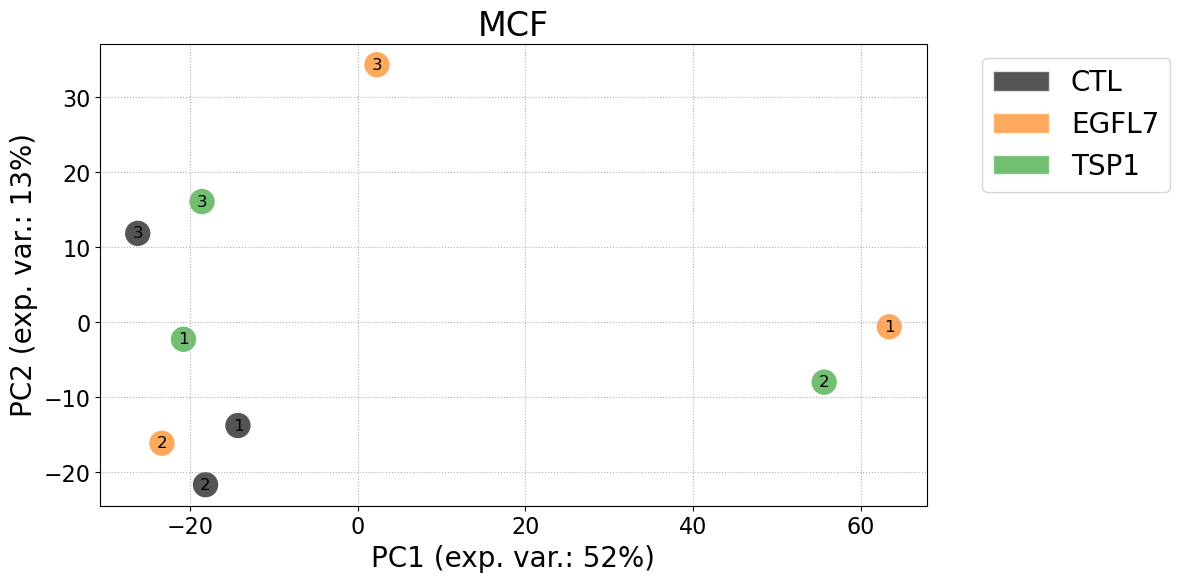

In [26]:
# what is happening with treatment with each of the four conditions
for label in ['TNBC', 'MDA', 'LumA', 'MCF']:
    print(label)
    print(expression.shape)
    filtered_df = expression.filter(like=label)
    print(filtered_df.shape, filtered_df.columns)

    local_high_df = filtered_df[filtered_df.max(axis=1) >= 100]
    print(local_high_df.shape)

    transpose = local_high_df.transpose()
    pca_high_expression = numpy.log2(transpose + 1)

    scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
    model = sklearn.decomposition.PCA(n_components=2)
    new = model.fit_transform(scaled_data)
    explained = model.explained_variance_ratio_
    print(explained)

    
    
    for i in range(len(new)):

        name = filtered_df.columns[i]

        # colors
        if 'cntr' in name:
            the_color = 'black'
        elif 'EGFL7' in name:
            the_color = 'tab:orange'
        elif 'TSP1' in name:
            the_color = 'tab:green'
        else:
            print('error')
    
        # marker
        if 'LumA' in name or 'TNBC' in name:
            the_marker = 's'
        elif 'MCF' in name or 'MDA' in name:
            the_marker = 'o'
        else:
            print('error')

        # figure text
        if '_1' in name:
            figure_text = '1'
        elif '_2' in name:
            figure_text = '2'
        elif '_3' in name:
            figure_text = '3'
        else:
            print('error')
            
        matplotlib.pyplot.scatter(new[i,0], new[i,1], s=333, c=the_color, marker=the_marker, alpha=2/3, edgecolors='none')
        
        epsilon=0
        matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, figure_text, size=12, va='center', ha='center')
    
    legend_elements = [
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black', edgecolor='white', alpha=2/3),
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange', edgecolor='white', alpha=2/3),
        matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:green', edgecolor='white', alpha=2/3)
    ]
    
    matplotlib.pyplot.legend(legend_elements, ['CTL', 'EGFL7', 'TSP1'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
        
    matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
    matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
    matplotlib.pyplot.grid(ls=':')
    matplotlib.pyplot.title(label)
    
    matplotlib.pyplot.show()

In [ ]:
# 5. distributions

In [ ]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

In [ ]:
found_max = 15.6
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    name = working_samples[i]

    # colors
    if 'LumA' in name:
        the_color = 'tab:red'
    elif 'MCF' in name:
        the_color = 'tab:orange'
    elif 'TNBC' in name:
        the_color = 'tab:blue'
    elif 'MDA' in name:
        the_color = 'tab:green'
    else:
        print('error')

    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=1/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])

legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',      edgecolor='white', alpha=1/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange',    edgecolor='white', alpha=1/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue', edgecolor='white', alpha=1/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:green',    edgecolor='white', alpha=1/2),
]


matplotlib.pyplot.legend(legend_elements, ['Lum A', 'MCF', 'TNBC', 'MDA'], ncol=1, loc='upper right')

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)